# Persona Methodology - Clean Analysis Notebook

This notebook contains:
1. Sample-based persona assignment analysis
2. Raw-data validation queries
3. Chart code for presentation-ready visuals

**Important note:**
- The persona assignment analysis below uses a sample (`LIMIT 200000`) for faster iteration.
- The raw persona-signal validation queries run on the full `activity_clean` table.
- Sample-based charts should be presented as **pattern-based**, not exact full-dataset counts.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = 'developer_project.duckdb'
con = duckdb.connect(DB_PATH)

print('Available tables:')
print(con.sql('SHOW TABLES').df())


Available tables:
                           name
0                activity_clean
1                  activity_raw
2  activity_score_mapping_clean
3    activity_score_mapping_raw
4                 contact_clean
5                   contact_raw
6            sdk_download_clean
7              sdk_download_raw


## 1. Load Sample Data

We use a sample for faster persona assignment testing.


In [2]:
query = '''
SELECT
    a.dev_contact AS developer_id,
    COALESCE(a.activity, '') AS activity,
    COALESCE(a.activity_name, '') AS activity_name,
    COALESCE(a.activity_type, '') AS activity_type,
    COALESCE(a.activity_role, '') AS activity_role,
    COALESCE(c.development_areas, '') AS development_areas,
    COALESCE(c.fields_of_interest, '') AS fields_of_interest
FROM activity_clean a
LEFT JOIN contact_clean c
    ON a.dev_contact = c.developer_id
LIMIT 200000
'''

df = con.sql(query).df()

print('\nShape of joined data:', df.shape)
print(df.head())



Shape of joined data: (200000, 7)
  developer_id      activity  \
0      6050909  DLI Training   
1      9414050  DLI Training   
2      4363573  DLI Training   
3      5297365  DLI Training   
4      6135310  DLI Training   

                                       activity_name      activity_type  \
0  Assemble a Simple Robot in Isaac Sim (Access e...  Self-Paced Online   
1                            Generative AI Explained  Self-Paced Online   
2  Fundamentals of Accelerated Computing with CUD...  Self-Paced Online   
3  [Access Expires 07/24/2026] Getting Started wi...  Self-Paced Online   
4  [Access Expires 07/24/2026] Getting Started wi...  Self-Paced Online   

  activity_role                                  development_areas  \
0      Attendee                                              Other   
1      Attendee  Agentic AI / Generative AI;Data Science;Trustw...   
2      Attendee  Data Science;Data Center / Cloud;Simulation / ...   
3      Attendee             Data Science;

## 2. Clean Text Fields


In [3]:
text_cols = [
    'activity',
    'activity_name',
    'activity_type',
    'activity_role',
    'development_areas',
    'fields_of_interest',
]

for col in text_cols:
    df[col] = df[col].fillna('').astype(str).str.lower()


## 3. Field Weights and Persona Keywords


In [4]:
FIELD_WEIGHTS = {
    'development_areas': 2.0,
    'fields_of_interest': 2.0,
    'activity_name': 1.5,
    'activity': 1.0,
    'activity_type': 0.25,
    'activity_role': 0.25,
}

PERSONA_KEYWORDS = {
    'CUDA': {
        'strong': [
            'cuda', 'cudnn', 'nccl', 'cutlass', 'rapids',
            'cublas', 'cufft', 'cusolver', 'curand'
        ],
        'weak': [
            'gpu acceleration', 'gpu computing', 'dali',
            'nsight', 'cuda toolkit'
        ]
    },
    'GenAI': {
        'strong': [
            'tensorrt', 'triton', 'nim', 'nemo', 'llm', 'rag',
            'huggingface', 'hugging face', 'generative ai',
            'stable diffusion', 'diffusion model', 'gpt',
            'llama', 'mistral', 'bert', 'langchain', 'llamaindex'
        ],
        'weak': [
            'transformer', 'inference', 'prompt engineering',
            'embedding', 'semantic search', 'model serving',
            'foundation model', 'multimodal'
        ]
    },
    'Robotics': {
        'strong': [
            'jetson', 'isaac', 'isaac sim', 'isaac lab',
            'robotics', 'robotic', 'ros', 'ros2',
            'deepstream', 'autonomous vehicle', 'driveworks', 'drive agx'
        ],
        'weak': [
            'edge ai', 'edge deployment', 'embedded ai',
            'autonomous', 'drone', 'lidar', 'slam',
            'perception', 'sensor fusion', 'iot'
        ]
    },
    'Simulation': {
        'strong': [
            'omniverse', 'openusd', 'digital twin', 'nucleus',
            'omniverse kit', 'omniverse extension'
        ],
        'weak': [
            'usd', 'synthetic data', 'physics simulation',
            '3d simulation', 'scene generation', 'ray tracing',
            'rendering pipeline', 'photorealistic'
        ]
    }
}

LEARNING_COMMUNITY_SIGNALS = [
    'forum', 'devtalk', 'community post',
    'certification', 'nvidia developer blog'
]


## 4. Row-Level Persona Scoring


In [5]:
def score_row(row: pd.Series) -> dict:
    scores = {persona: 0.0 for persona in PERSONA_KEYWORDS}

    for field, weight in FIELD_WEIGHTS.items():
        text = row.get(field, '')
        if not text:
            continue

        for persona, groups in PERSONA_KEYWORDS.items():
            field_score = 0.0

            for kw in groups['strong']:
                if kw in text:
                    field_score += 2.0

            for kw in groups['weak']:
                if kw in text:
                    field_score += 1.0

            scores[persona] += field_score * weight

    return scores

print('Scoring rows...')
row_scores = df.apply(score_row, axis=1)
row_scores_df = pd.DataFrame(list(row_scores))

for col in row_scores_df.columns:
    df[f'{col}_row_score'] = row_scores_df[col]

score_cols = [c for c in df.columns if c.endswith('_row_score')]

print('\nScored row sample:')
print(df[['developer_id', 'activity_name'] + score_cols].head())


Scoring rows...

Scored row sample:
  developer_id                                      activity_name  \
0      6050909  assemble a simple robot in isaac sim (access e...   
1      9414050                            generative ai explained   
2      4363573  fundamentals of accelerated computing with cud...   
3      5297365  [access expires 07/24/2026] getting started wi...   
4      6135310  [access expires 07/24/2026] getting started wi...   

   CUDA_row_score  GenAI_row_score  Robotics_row_score  Simulation_row_score  
0             0.0              0.0                 6.0                   0.0  
1             0.0              7.0                 0.0                   0.0  
2             3.0              0.0                 0.0                   0.0  
3             0.0              0.0                 0.0                   0.0  
4             0.0              0.0                 0.0                   0.0  


## 5. Learning / Community Fallback Signal


In [6]:
def has_learning_signal(row: pd.Series) -> bool:
    combined = ' '.join([row.get(f, '') for f in FIELD_WEIGHTS.keys()])
    return any(sig in combined for sig in LEARNING_COMMUNITY_SIGNALS)

df['learning_signal'] = df.apply(has_learning_signal, axis=1)


## 6. Aggregate to Developer Level


In [7]:
agg_dict = {col: 'mean' for col in score_cols}
agg_dict['learning_signal'] = 'max'

developer_scores = (
    df.groupby('developer_id', dropna=False)
      .agg(agg_dict)
      .reset_index()
)

row_counts = (
    df.groupby('developer_id', dropna=False)
      .size()
      .reset_index(name='row_count')
)

developer_scores = developer_scores.merge(row_counts, on='developer_id', how='left')

developer_scores.rename(columns={
    'CUDA_row_score': 'CUDA_score',
    'GenAI_row_score': 'GenAI_score',
    'Robotics_row_score': 'Robotics_score',
    'Simulation_row_score': 'Simulation_score',
}, inplace=True)

persona_score_cols = ['CUDA_score', 'GenAI_score', 'Robotics_score', 'Simulation_score']

print('\nDeveloper-level score sample:')
print(developer_scores[['developer_id', 'row_count'] + persona_score_cols].head())



Developer-level score sample:
  developer_id  row_count  CUDA_score  GenAI_score  Robotics_score  \
0     10000110          1         0.0          6.0             0.0   
1     10000124          1         0.0          4.0             0.0   
2     10000161          1         0.0          4.0             8.0   
3     10000285          1         1.5          0.0             0.0   
4     10000343          1         0.0          4.0             8.0   

   Simulation_score  
0               0.0  
1               0.0  
2               0.0  
3               0.0  
4               0.0  


## 7. Assign Final Persona


In [8]:
MIN_SCORE_THRESHOLD = 1.0

def assign_persona(row: pd.Series) -> pd.Series:
    scores = {
        'CUDA': row['CUDA_score'],
        'GenAI': row['GenAI_score'],
        'Robotics': row['Robotics_score'],
        'Simulation': row['Simulation_score'],
    }

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top1_persona, top1_score = sorted_scores[0]
    top2_persona, top2_score = sorted_scores[1]
    total_score = sum(scores.values())

    if top1_score >= MIN_SCORE_THRESHOLD:
        final_persona = top1_persona
        if top1_score >= 3.0:
            confidence_tier = 'HIGH'
        elif top1_score >= 1.5:
            confidence_tier = 'MEDIUM'
        else:
            confidence_tier = 'LOW'
    elif row.get('learning_signal', False):
        final_persona = 'Learning_Community'
        confidence_tier = 'FALLBACK'
    else:
        final_persona = 'Unknown'
        confidence_tier = 'FALLBACK'

    if top1_score > 0 and top2_score > 0:
        mixed_flag = (top2_score / top1_score) >= 0.75
    else:
        mixed_flag = False

    if total_score > 0:
        dominance = top1_score / total_score
    else:
        dominance = 0.0

    return pd.Series({
        'final_persona': final_persona,
        'confidence_tier': confidence_tier,
        'top1_persona': top1_persona,
        'top1_score': round(top1_score, 3),
        'top2_persona': top2_persona,
        'top2_score': round(top2_score, 3),
        'mixed_flag': mixed_flag,
        'dominance': round(dominance, 3),
    })

persona_assignments = developer_scores.apply(assign_persona, axis=1)
developer_personas = pd.concat([developer_scores, persona_assignments], axis=1)

print('\nFinal persona sample:')
print(developer_personas.head(10))



Final persona sample:
  developer_id  CUDA_score  GenAI_score  Robotics_score  Simulation_score  \
0     10000110         0.0          6.0             0.0               0.0   
1     10000124         0.0          4.0             0.0               0.0   
2     10000161         0.0          4.0             8.0               0.0   
3     10000285         1.5          0.0             0.0               0.0   
4     10000343         0.0          4.0             8.0               0.0   
5     10000588         0.0          0.0             0.0               0.0   
6     10000649         0.0          6.0             0.0               0.0   
7     10000744         0.0          4.0             8.0               0.0   
8     10000921         0.0          4.0             0.0               0.0   
9     10001007         0.0         10.0             8.0               0.0   

   learning_signal  row_count final_persona confidence_tier top1_persona  \
0            False          1         GenAI          

## 8. Distribution Checks


In [9]:
print('\n=== PERSONA DISTRIBUTION ===')
print(developer_personas['final_persona'].value_counts(dropna=False))

print('\n=== CONFIDENCE TIER ===')
print(developer_personas['confidence_tier'].value_counts(dropna=False))

print('\n=== MIXED FLAG ===')
print(developer_personas['mixed_flag'].value_counts(dropna=False))

print('\n=== MEAN DOMINANCE BY PERSONA ===')
print(
    developer_personas.groupby('final_persona')['dominance']
    .mean()
    .sort_values(ascending=False)
)



=== PERSONA DISTRIBUTION ===
final_persona
GenAI         75633
Robotics      36639
Unknown       24029
CUDA           8153
Simulation     2896
Name: count, dtype: int64

=== CONFIDENCE TIER ===
confidence_tier
HIGH        117314
FALLBACK     24029
MEDIUM        5341
LOW            666
Name: count, dtype: int64

=== MIXED FLAG ===
mixed_flag
False    131096
True      16254
Name: count, dtype: int64

=== MEAN DOMINANCE BY PERSONA ===
final_persona
CUDA          0.946996
GenAI         0.928307
Simulation    0.859862
Robotics      0.768707
Unknown       0.034011
Name: dominance, dtype: float64


## 9. Raw Data Validation Query

This runs on the full activity table and checks whether the persona signals exist directly in raw activity names.


In [10]:
raw_signal_counts = con.sql('''
SELECT
  CASE
    WHEN LOWER(activity_name) LIKE '%tensorrt%'
      OR LOWER(activity_name) LIKE '%llm%'
      OR LOWER(activity_name) LIKE '%generative ai%'
      OR LOWER(activity_name) LIKE '%rag%'
      THEN 'GenAI'
    WHEN LOWER(activity_name) LIKE '%jetson%'
      OR LOWER(activity_name) LIKE '%isaac%'
      OR LOWER(activity_name) LIKE '%robot%'
      OR LOWER(activity_name) LIKE '%deepstream%'
      THEN 'Robotics'
    WHEN LOWER(activity_name) LIKE '%cuda%'
      OR LOWER(activity_name) LIKE '%cudnn%'
      OR LOWER(activity_name) LIKE '%gpu acceleration%'
      THEN 'CUDA'
    WHEN LOWER(activity_name) LIKE '%omniverse%'
      OR LOWER(activity_name) LIKE '%openusd%'
      OR LOWER(activity_name) LIKE '%digital twin%'
      OR LOWER(activity_name) LIKE '%usd%'
      THEN 'Simulation'
    ELSE 'Other'
  END AS persona_signal,
  COUNT(*) AS cnt
FROM activity_clean
GROUP BY 1
ORDER BY cnt DESC
''').df()

raw_signal_counts


,persona_signal,cnt
0,Other,52841626
1,CUDA,11326067
2,GenAI,2708962
3,Robotics,2097285
4,Simulation,373586


## 10. Investigate the “Other” Bucket


In [11]:
other_sample = con.sql('''
SELECT activity_name
FROM activity_clean
WHERE NOT (
    LOWER(activity_name) LIKE '%tensorrt%'
 OR LOWER(activity_name) LIKE '%llm%'
 OR LOWER(activity_name) LIKE '%generative ai%'
 OR LOWER(activity_name) LIKE '%rag%'
 OR LOWER(activity_name) LIKE '%jetson%'
 OR LOWER(activity_name) LIKE '%isaac%'
 OR LOWER(activity_name) LIKE '%robot%'
 OR LOWER(activity_name) LIKE '%deepstream%'
 OR LOWER(activity_name) LIKE '%cuda%'
 OR LOWER(activity_name) LIKE '%cudnn%'
 OR LOWER(activity_name) LIKE '%gpu acceleration%'
 OR LOWER(activity_name) LIKE '%omniverse%'
 OR LOWER(activity_name) LIKE '%openusd%'
 OR LOWER(activity_name) LIKE '%digital twin%'
 OR LOWER(activity_name) LIKE '%usd%'
)
LIMIT 50
''').df()

other_sample


,activity_name
0,Getting Started with Deep Learning
1,(COURSE ENDING ON 7/1/24) High-Performance Com...
2,Getting Started with Deep Learning
3,Prompt Engineering with LLaMA-2 (Access Expire...
4,Getting Started with Deep Learning
5,Data Augmentation and Segmentation with Genera...
6,Modeling Time Series Data with Recurrent Neura...
7,Building Real-Time Video AI Applications
8,Accelerating End-to-End Data Science Workflows...
9,Getting Started with Deep Learning


In [12]:
other_top = con.sql('''
SELECT activity_name, COUNT(*) AS cnt
FROM activity_clean
WHERE NOT (
    LOWER(activity_name) LIKE '%tensorrt%'
 OR LOWER(activity_name) LIKE '%llm%'
 OR LOWER(activity_name) LIKE '%generative ai%'
 OR LOWER(activity_name) LIKE '%rag%'
 OR LOWER(activity_name) LIKE '%jetson%'
 OR LOWER(activity_name) LIKE '%isaac%'
 OR LOWER(activity_name) LIKE '%robot%'
 OR LOWER(activity_name) LIKE '%deepstream%'
 OR LOWER(activity_name) LIKE '%cuda%'
 OR LOWER(activity_name) LIKE '%cudnn%'
 OR LOWER(activity_name) LIKE '%gpu acceleration%'
 OR LOWER(activity_name) LIKE '%omniverse%'
 OR LOWER(activity_name) LIKE '%openusd%'
 OR LOWER(activity_name) LIKE '%digital twin%'
 OR LOWER(activity_name) LIKE '%usd%'
)
GROUP BY activity_name
ORDER BY cnt DESC
LIMIT 20
''').df()

other_top


100% ▕██████████████████████████████████████▏ (00:00:04.53 elapsed)     


,activity_name,cnt
0,JetPack SDK,10316702
1,jetpack,7365167
2,Developer,6527784
3,JetPack,2291461
4,OTHER,1159886
5,PyTorch,587515
6,sdkmanager,485480
7,ai-deepseek-r1,427318
8,Triton Inference Server,421559
9,ai-deepseek-v3_1,411394


## 11. Chart 1 - Raw Persona Signals (Full Data)

This is your strongest data-validation chart.


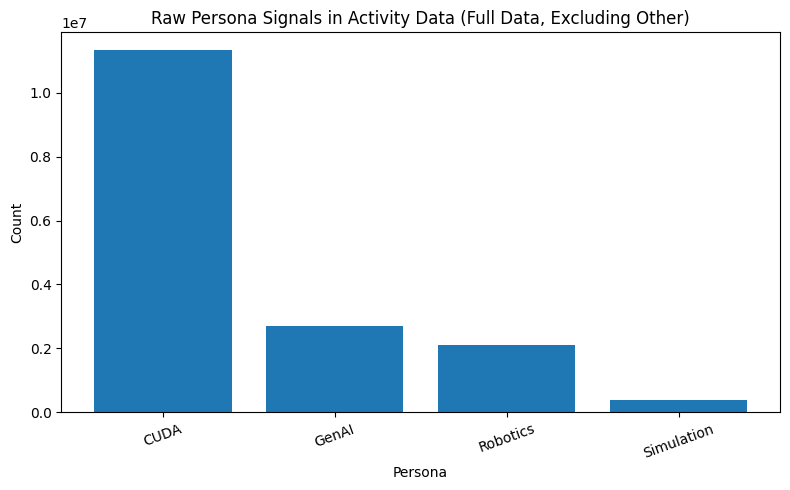

In [13]:
chart1 = raw_signal_counts[raw_signal_counts['persona_signal'] != 'Other'].copy()

plt.figure(figsize=(8, 5))
plt.bar(chart1['persona_signal'], chart1['cnt'])
plt.title('Raw Persona Signals in Activity Data (Full Data, Excluding Other)')
plt.xlabel('Persona')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 12. Chart 2 - Final Persona Distribution (Sample-Based)

This chart is based on the sample-driven assignment pipeline.


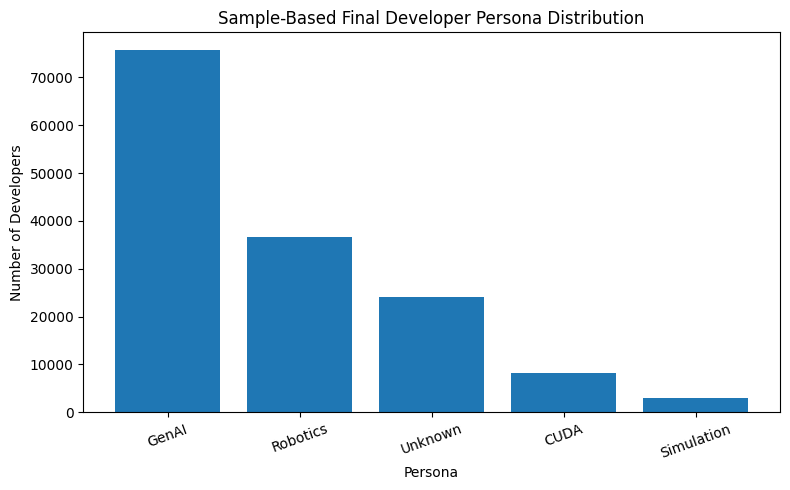

In [14]:
persona_dist = developer_personas['final_persona'].value_counts().reset_index()
persona_dist.columns = ['final_persona', 'count']

plt.figure(figsize=(8, 5))
plt.bar(persona_dist['final_persona'], persona_dist['count'])
plt.title('Sample-Based Final Developer Persona Distribution')
plt.xlabel('Persona')
plt.ylabel('Number of Developers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 13. Chart 3 - Mapped vs Other (Optional Limitation Chart)


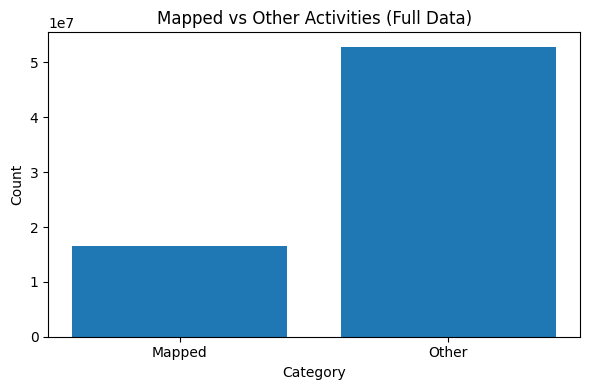

In [15]:
mapped_count = raw_signal_counts.loc[raw_signal_counts['persona_signal'] != 'Other', 'cnt'].sum()
other_count = raw_signal_counts.loc[raw_signal_counts['persona_signal'] == 'Other', 'cnt'].iloc[0]

mapped_vs_other = pd.DataFrame({
    'category': ['Mapped', 'Other'],
    'count': [mapped_count, other_count]
})

plt.figure(figsize=(6, 4))
plt.bar(mapped_vs_other['category'], mapped_vs_other['count'])
plt.title('Mapped vs Other Activities (Full Data)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 14. Save Outputs


In [16]:
developer_personas.to_csv('developer_personas_final.csv', index=False)
other_top.to_csv('other_top_activities.csv', index=False)
raw_signal_counts.to_csv('raw_persona_signal_counts.csv', index=False)

print('Saved:')
print('- developer_personas_final.csv')
print('- other_top_activities.csv')
print('- raw_persona_signal_counts.csv')


Saved:
- developer_personas_final.csv
- other_top_activities.csv
- raw_persona_signal_counts.csv
